# Convolutional Neural Network

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator


c:\Users\Alex\anaconda3\envs\hindi-digits\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 2.1.0 when it was built against 2.0.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [3]:
TRAIN = "train.csv"
TEST = "test.csv"
TRAIN_DIR = "train/train"
TEST_DIR = "test/test"

train_df = pd.read_csv(TRAIN)
test_df = pd.read_csv(TEST)

print("Train shape: ", train_df.shape)
print("Test shape: ", test_df.shape)
print(train_df.head())

Train shape:  (17000, 2)
Test shape:  (3000, 1)
      Id  Category
0   7168         6
1   9876         3
2  78117         6
3   9626         1
4  29492         3


In [4]:
def load_image(image_id, folder):
    # load image as grayscale float32 in [0,1]
    path = os.path.join(folder, f"{image_id}.png")
    img = cv2.imread(path, 0) # grayscale
    img = img.astype(np.float32) / 255.0
    return img

def load_train_dataset(df, folder):
    X_images = []
    y = []

    for i, row in df.iterrows():
        image_id = int(row["Id"])
        label = int(row["Category"])

        path = os.path.join(folder, str(label), f"{image_id}.png")
        img = cv2.imread(path, 0)

        if img is None:
            raise FileNotFoundError(f"Could not read image: {path}")

        img = img.astype(np.float32) / 255.0
        X_images.append(img)
        y.append(label)

        if i % 1000 == 0:
            print("Loaded", i, "images")

    return np.array(X_images, dtype=np.float32), np.array(y)

In [5]:
X_images, y = load_train_dataset(train_df, TRAIN_DIR)

print("X_images shape:", X_images.shape)
print("y shape:", y.shape)
print("Pixel range:", X_images.min(), "to", X_images.max())

Loaded 0 images
Loaded 1000 images
Loaded 2000 images
Loaded 3000 images
Loaded 4000 images
Loaded 5000 images
Loaded 6000 images
Loaded 7000 images
Loaded 8000 images
Loaded 9000 images
Loaded 10000 images
Loaded 11000 images
Loaded 12000 images
Loaded 13000 images
Loaded 14000 images
Loaded 15000 images
Loaded 16000 images
X_images shape: (17000, 32, 32)
y shape: (17000,)
Pixel range: 0.0 to 1.0


In [6]:
X_train_img, X_val_img, y_train, y_val = train_test_split(
    X_images,
    y,
    test_size=0.2,
    random_state=69,
    stratify=y
)

print("Train: ", X_train_img.shape, y_train.shape)
print("Val: ", X_val_img.shape, y_val.shape)

Train:  (13600, 32, 32) (13600,)
Val:  (3400, 32, 32) (3400,)


# Reshape for CNN

In [7]:
X_train_cnn = X_train_img.reshape(-1, 32, 32, 1)
X_val_cnn = X_val_img.reshape(-1, 32, 32, 1)

print("X_train_cnn:", X_train_cnn.shape)
print("X_val_cnn:", X_val_cnn.shape)

X_train_cnn: (13600, 32, 32, 1)
X_val_cnn: (3400, 32, 32, 1)


In [8]:
def build_cnn():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 1)),

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        
        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,562 (4.36 MB)

 Trainable params: 1,143,114 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

# Callbacks

In [9]:
callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitors="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        "best_cnn_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

# Train CNN

In [10]:
history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=25,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8776 - loss: 0.4472
Epoch 1: val_accuracy improved from None to 0.20235, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.9410 - loss: 0.2033 - val_accuracy: 0.2024 - val_loss: 6.2974 - learning_rate: 0.0010
Epoch 2/25
211/213 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9855 - loss: 0.0547
Epoch 2: val_accuracy improved from 0.20235 to 0.81176, saving model to best_cnn_model.keras

Epoch 2: finished saving model to best_cnn_model.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9865 - loss: 0.0513 - val_accuracy: 0.8118 - val_loss: 0.8951 - learning_rate: 0.0010
Epoch 3/25
211/213 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9897 - loss: 0.0425
Epoch 3: val_accuracy improved from 0.81176 to 0.98941, saving model to best_cnn_model.keras

Epoch 3: finished saving model to best_cnn_model.keras
213/213 ━━━

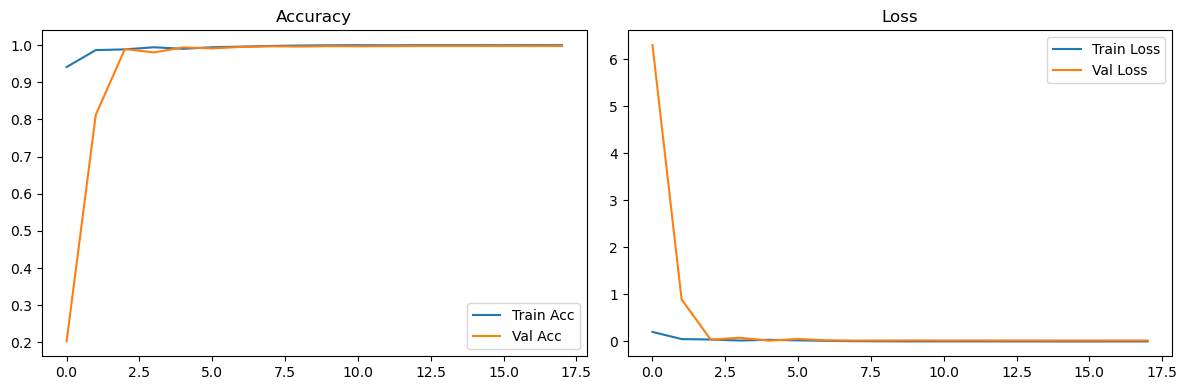

In [11]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate on validation set

In [12]:
val_loss, val_acc = cnn_model.evaluate(X_val_cnn, y_val, verbose=0)
print("CNN Validation Accuracy: ", val_acc)

CNN Validation Accuracy:  0.9973529577255249


In [13]:
val_probs = cnn_model.predict(X_val_cnn)
val_pred = np.argmax(val_probs, axis=1)

print(classification_report(y_val, val_pred, digits=6))

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

           0   1.000000  0.997059  0.998527       340
           1   0.997067  1.000000  0.998532       340
           2   0.997050  0.994118  0.995582       340
           3   1.000000  0.994118  0.997050       340
           4   0.994152  1.000000  0.997067       340
           5   0.991228  0.997059  0.994135       340
           6   0.997067  1.000000  0.998532       340
           7   1.000000  0.991176  0.995569       340
           8   0.997067  1.000000  0.998532       340
           9   1.000000  1.000000  1.000000       340

    accuracy                       0.997353      3400
   macro avg   0.997363  0.997353  0.997352      3400
weighted avg   0.997363  0.997353  0.997352      3400



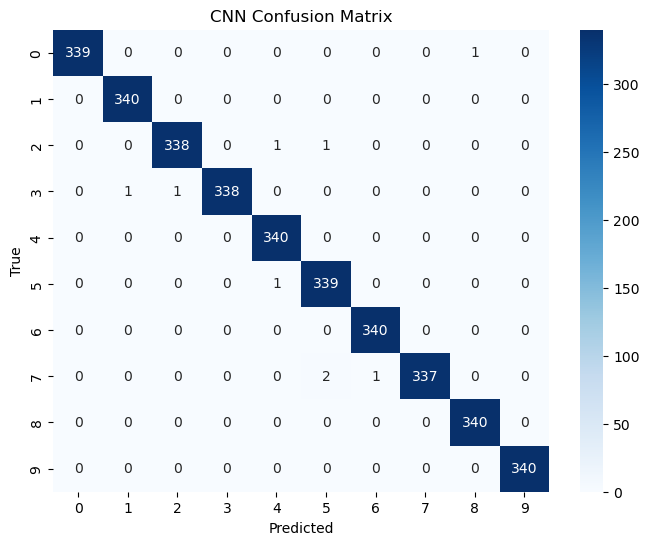

In [14]:
cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CNN Confusion Matrix")
plt.show()

Number of misclassified samples: 9


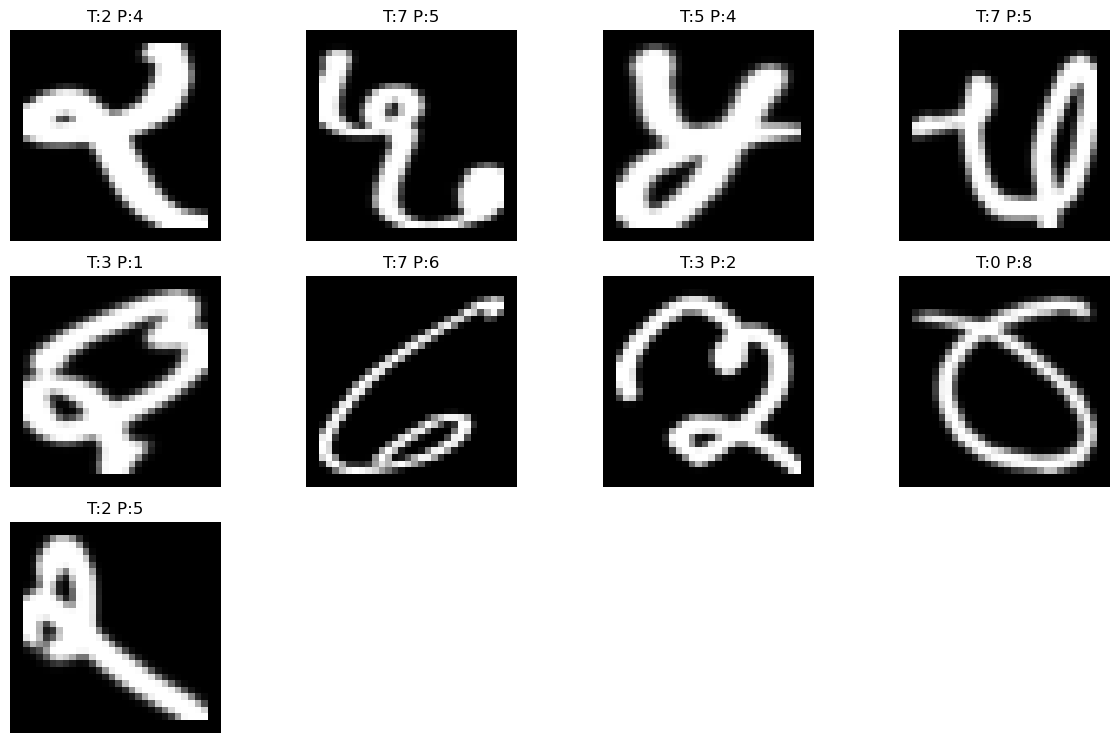

In [15]:
wrong_idx = np.where(val_pred != y_val)[0]
print("Number of misclassified samples:", len(wrong_idx))

plt.figure(figsize=(12, 10))
n_show = min(16, len(wrong_idx))

for i in range(n_show):
    idx = wrong_idx[i]
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_val_img[idx], cmap="gray")
    plt.title(f"T:{y_val[idx]} P:{val_pred[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# CNN + augmentation

In [16]:

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08
)

train_datagen.fit(X_train_cnn)

# Build new model for augmentation

In [17]:

cnn_aug = build_cnn()
cnn_aug.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,562 (4.36 MB)

 Trainable params: 1,143,114 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [18]:
callbacks_aug = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        "best_cnn_aug_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

history_aug = cnn_aug.fit(
    train_datagen.flow(X_train_cnn, y_train, batch_size=64),
    validation_data=(X_val_cnn, y_val),
    epochs=30,
    callbacks=callbacks_aug,
    verbose=1
)

Epoch 1/30
212/213 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8213 - loss: 0.5903
Epoch 1: val_accuracy improved from None to 0.14765, saving model to best_cnn_aug_model.keras

Epoch 1: finished saving model to best_cnn_aug_model.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9074 - loss: 0.3037 - val_accuracy: 0.1476 - val_loss: 8.2232 - learning_rate: 0.0010
Epoch 2/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9680 - loss: 0.0977
Epoch 2: val_accuracy improved from 0.14765 to 0.85647, saving model to best_cnn_aug_model.keras

Epoch 2: finished saving model to best_cnn_aug_model.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9720 - loss: 0.0925 - val_accuracy: 0.8565 - val_loss: 0.5056 - learning_rate: 0.0010
Epoch 3/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9753 - loss: 0.0790
Epoch 3: val_accuracy improved from 0.85647 to 0.99176, saving model to best_cnn_aug_model.keras

Epoch 3: finished saving model to best_cnn_aug

In [19]:
val_loss_aug, val_acc_aug = cnn_aug.evaluate(X_val_cnn, y_val, verbose=0)
print("CNN + Augmentation Validation Accuracy:", val_acc_aug)

CNN + Augmentation Validation Accuracy: 0.9985294342041016


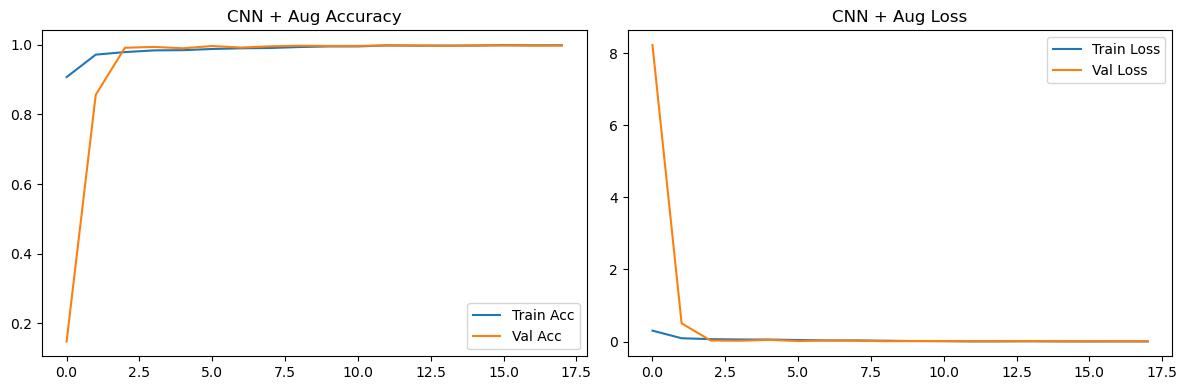

In [20]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_aug.history["accuracy"], label="Train Acc")
plt.plot(history_aug.history["val_accuracy"], label="Val Acc")
plt.title("CNN + Aug Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_aug.history["loss"], label="Train Loss")
plt.plot(history_aug.history["val_loss"], label="Val Loss")
plt.title("CNN + Aug Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
print("Plain CNN Accuracy: ", val_acc)
print("CNN + Augmentation Accuracy: ", val_acc_aug)

Plain CNN Accuracy:  0.9973529577255249
CNN + Augmentation Accuracy:  0.9985294342041016
